In [20]:
%matplotlib inline
import math
import time
import numpy as np
import torch
import d2l
import time
import random
from torch.utils import data
from torch import nn
from IPython import display

# 线性回归

In [62]:
n = 10000
a = torch.ones([n])
b = torch.ones([n])
a , b

(tensor([1., 1., 1.,  ..., 1., 1., 1.]),
 tensor([1., 1., 1.,  ..., 1., 1., 1.]))

In [63]:
class Timer: #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self): #Python 官方的列表只有 append、pop、sort 这些基础功能，没有cumsum()
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()
        

In [64]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
print(f'{timer.stop():.5f} sec')

0.02965 sec


In [65]:
timer.start() #因为上面stop了，所以必须重新开始
d = a + b
print(f'{timer.stop():.5f} sec')

0.00142 sec


In [66]:
def normal(x, mu, sigma):
    p = 1/math.sqrt(2 * math.pi * sigma **2)
    return p * np.exp(-0.5/sigma **2 * (x -mu)**2)

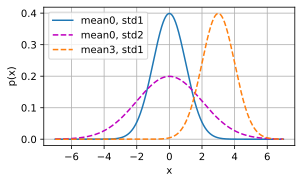

In [67]:
#再次使用numpy进行可视化
x = np.arange(-7, 7, 0.01)

# 均值和标准差化
params = [(0,1), (0,2), (3,1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x', ylabel='p(x)', figsize=(4.5, 2.5),
        legend=[f'mean{mu}, std{sigma}' for mu, sigma in params])

## 3.2

In [68]:
def synthetic_data(w, b, num_examples): #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w))) #len(w) 代表了你这个回归模型中“输入特征的个数”（即因变量的维度）
    y = torch.matmul(X, w) + b #矩阵乘法，维度会发生变化
    y += torch.normal(0, 0.01, y.shape) #加噪音
    return X, y.reshape((-1, 1)) #-1 代表让系统自动去算行数（系统自动填入 1000）,1 代表固定为 1 列，为了防止反向传播疯狂复制导致计算爆炸

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)


In [69]:
features[0], labels[0]

(tensor([-1.1209, -0.2829]), tensor([2.9199]))

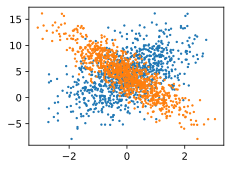

In [70]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 0].detach().numpy(), labels.detach().numpy(), 2)
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 2)

In [71]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]
        #return 是“一次性全打包带走”，而 yield 是“吃自助餐，吃多少拿多少（迭代器）

In [72]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break #这里的 break 导致程序只取了第一个 Batch，然后就立刻结束了

tensor([[ 1.2292, -1.0766],
        [ 0.6800, -1.8483],
        [ 0.0559,  0.5572],
        [-1.5875, -1.2456],
        [ 0.5988, -0.3248],
        [-1.2075,  0.4139],
        [-0.8780, -0.5816],
        [ 1.4622, -0.2111],
        [-0.7473, -0.3039],
        [-0.7080,  1.1512]]) 
 tensor([[10.3090],
        [11.8559],
        [ 2.4218],
        [ 5.2625],
        [ 6.5196],
        [ 0.3793],
        [ 4.4156],
        [ 7.8287],
        [ 3.7425],
        [-1.1304]])


In [73]:
# 初始化模型参数
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True) #（均值为 0，方差为 0.01 的正态分布）
b = torch.zeros(1, requires_grad=True)
w, b

(tensor([[ 0.0037],
         [-0.0113]], requires_grad=True),
 tensor([0.], requires_grad=True))

In [74]:
#定义模型
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b
#定义损失函数
def squared_loss(y_hat, y):
    return (y_hat-y) **2/2

部门一：反向传播（Backpropagation）—— 负责“算”
loss.backward()  # 👈 这才是真正的反向传播！
- 它在干什么：PyTorch 顺着我们之前聊过的“隐形录像带（计算图）”，从最后的损失 loss 开始，利用微积分的链式法则，一路往回倒推，计算出每个参数的梯度。
- 它的产物：它把算出来的结果安安静静地存放在了每一个参数的 .grad 属性里。此时，参数（比如 w 和 b）的值纹丝不动，根本没有变，只是它们身上多了一堆被称为“梯度”的数字。

部门二：梯度下降优化器（SGD） —— 负责“用”
- 它在干什么：此时，反向传播已经彻底结束，录像机也已经关了（with torch.no_grad():）。这个函数纯粹是一个执行者。
- 它的产物：它直接去读取刚才反向传播存放在 param.grad 里的数字，顺着这个方向把参数的值减掉一点（param -= ...），从而完成了真正改变参数数值的动作。

In [75]:
# 反向传播负责“算”梯度，而 SGD 负责“用”梯度
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad(): #PyTorch 默认长了一双“复眼”，只要你对 Tensor 进行任何数学运算（比如加减乘除），它就会自动开启隐形录像带把过程记录在计算图里，用来算梯度。
        #如果我们不把 PyTorch 的监控关掉，PyTorch 就会把“更新权重的数学公式”也记录到下一轮的梯度计算中去，导致计算图无限膨胀，内存直接爆炸！
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_() #param.grad.zero_() 后面的下划线 _ 在 PyTorch 里代表 In-place（原地修改）

In [76]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y) #X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size) #使用参数的梯度分别更新w和b
        # X是features[batch_indices]，y是labels[batch_indices]
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')
        # features 是所有样本的特征，labels 是所有样本的标签
        

epoch 1, loss 0.034352
epoch 2, loss 0.000121
epoch 3, loss 0.000044


带括号 linreg()：代表“立刻执行这个函数”。如果这里写成 net = linreg()，Python 会马上运行它，然后把函数运行完返回的最终结果赋给 net。但因为你现在连输入数据 X, w, b 都没传进去，直接执行必然会报错。

不带括号 linreg：代表“给这个函数起个别名（传递函数指针）”。Python 允许把函数当成一个普通的变量传来传去。这一步的意思是：“我把 linreg 这个函数本身，打包贴上了一个叫 net 的新标签。”

后面在写训练循环时，我们可以统一使用 net(X, w, b) 来调用模型。
如果你明天想把线性回归（linreg）换成多层感知机（比如 mlp），你只需要把最上面的准备工作改成 net = mlp，下面的整个 for 循环代码一个字都不用改！这就是为什么李沐老师要故意兜个圈子给它起个别名的原因。

In [77]:
print(f'w的估计误差:{true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差:{true_b - b}')

w的估计误差:tensor([ 0.0007, -0.0007], grad_fn=<SubBackward0>)
b的估计误差:tensor([0.0008], grad_fn=<RsubBackward1>)


w：是在网络训练中不断被更新的权重参数。因为在反向传播和矩阵乘法 X @ w 的现实需要中，w 的真实状态往往背着一个二维的包袱，通常是一个二维列向量：

形状是 torch.Size([2, 1])，里面长这样：tensor([[2.0001], [-3.3999]])

## 3.3

In [102]:
def load_array(data_arrays, batch_size, is_train=True): #@save
    """构造一个PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    # *data_arrays（星号解包操作）：这是 Python 的一个核心语法糖。星号的意思是“把这个包裹拆开，把里面的元素一个一个单独传进去”。
    # 所以，data.TensorDataset(*data_arrays) 在底层等价于：data.TensorDataset(features, labels)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)


In [103]:
batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [104]:
next(iter(data_iter)) #提取第一个batch

[tensor([[ 2.2971,  0.2581],
         [-1.4881,  0.4668],
         [ 1.2933, -1.6011],
         [ 0.9837,  1.2668],
         [ 0.9621, -0.5010],
         [-0.0248, -0.0047],
         [ 0.3283, -1.8706],
         [-2.3864,  1.1258],
         [ 1.7628,  1.0218],
         [-1.8078, -0.7104]]),
 tensor([[ 7.9091],
         [-0.3698],
         [12.2387],
         [ 1.8643],
         [ 7.8332],
         [ 4.1554],
         [11.2129],
         [-4.4027],
         [ 4.2482],
         [ 2.9937]])]

In [105]:
net = nn.Sequential(nn.Linear(2,1))
#第一个指定输入特征形状，即2，第二个指定输出特征形状，输出特征形状为单个标量，因此为1

In [106]:
## 初始化模型, 直接访问参数以设定它们的初始值
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)
# 在 PyTorch 官方定义的网络里，weight 和 bias 默认是背着“反向传播监控录像带”（requires_grad=True）的。如果你直接去改写它们，PyTorch 的计算图机制又会报错。
# 通过加上 .data，相当于告诉 PyTorch：“别紧张，我只是想直接修改它们底层的纯数字，不需要你记录任何梯度计算图。” 这相当于我们在前面自己手写代码时的 with torch.no_grad(): 的局部简写版

tensor([0.])

In [107]:
## 定义损失函数
loss = nn.MSELoss()
# 计算均方误差使用的是MSELoss类，也称为平方L2范数。 默认情况下，它返回所有样本损失的平均值。

## 定义优化算法
# 小批量随机梯度下降算法是一种优化神经网络的标准工具。pytorch在optim模块中实现了该算法
# 当我们实例化一个SGD实例时，我们要指定优化的参数 （可通过net.parameters()从我们的模型中获得）以及优化算法所需的超参数字典。 
# 小批量随机梯度下降只需要设置lr值
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

在每个迭代周期里，我们将完整遍历一次数据集（train_data）， 不停地从中获取一个小批量的输入和相应的标签。 对于每一个小批量，我们会进行以下步骤:

- 通过调用net(X)生成预测并计算损失l（前向传播）。

- 通过进行反向传播来计算梯度。

- 通过调用优化器来更新模型参数。

In [108]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)  # 1. 前向传播（Forward Pass）算损失
        trainer.zero_grad()  # 2. 倒空垃圾（Zero Gradient）
        l.backward()         # 3. 反向传播（Backward Pass）算梯度
        trainer.step()       # 4. 迈出一步（Optimizer Step）更新参数
    l = loss(net(features), labels) # 前面循环里的 loss 是为了“学习（修改参数）”，后面外层的 loss 是为了“做期末大盘点（汇报成绩）
    print(f'epoch {epoch + 1}, loss {l:f}')

# 为什么这里李沐老师没有写 with torch.no_grad(): 也能直接跑？
# 因为这里只是纯粹地算一个 l 出来并打印，我们并没有在后面调用 l.backward()。
# 虽然 PyTorch 依然在偷偷地录像，但由于这一轮 Epoch 已经彻底结束了，下一轮一进来马上就会触发 trainer.zero_grad() 把录像机里的梯度清空。
# 所以在这里即便不写 no_grad()，内存也不会像在训练循环内部那样发生连续叠加而爆炸，属于官方高阶实现里一种稍微偷懒但完全安全的写法。

epoch 1, loss 0.000200
epoch 2, loss 0.000089
epoch 3, loss 0.000088


In [ ]:
w = net[0].weight.data
print(f'w的估计误差:{true_w - w.reshape(true_w.shape)}')
b = net[0].bias.data
print(f'b的估计误差:{true_b - b}')

w的估计误差:tensor([ 0.0003, -0.0001])
b的估计误差:tensor([3.7193e-05])


查看深度学习框架文档，它们提供了哪些损失函数和初始化方法？用 Huber 损失代替原损失。
🔧 框架文档盘点（以 PyTorch 为例）：
常用损失函数（在 torch.nn 模块下）：

- nn.MSELoss：均方误差（L2 Loss），适用于普通回归。

- nn.L1Loss：绝对值误差（L1 Loss），对异常值更鲁棒。

- nn.CrossEntropyLoss：交叉熵损失，用于多分类问题。

常用初始化方法（在 torch.nn.init 模块下）：

- init.normal_ / init.uniform_：正态分布 / 均匀分布初始化。

- init.xavier_normal_ (Glorot)：专门针对 Sigmoid/Tanh 激活函数的经典深层网络初始化。

- init.kaiming_normal_ (He)：专门针对 ReLU 激活函数的经典深层网络初始化。

🎯 Huber 损失的物理含义与代码替换：Huber 损失是一个非常聪明的“缝合怪”。从图片里的公式可以看出：
- 当误差很小（$\le \sigma$）时，它呈现 平方损失 的特征，导数平滑，方便模型在终点附近精准微调。
- 当误差很大（$> \sigma$）时，它呈现 绝对值（线性）损失 的特征，导数恒定，防止因为数据里有几个极端的“脏数据/异常值（Outliers）”而产生过大的梯度，把模型彻底带偏。

---
# softmax

写SQL

In [3]:
import torchvision
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

In [9]:
# 通过ToTensor实例将图像数据从PIL类型变换成32位浮点数格式，
# 并除以255使得所有像素的数值均在0～1之间
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

100.0%
100.0%
100.0%
100.0%


In [11]:
len(mnist_train), len(mnist_test)

(60000, 10000)

In [13]:
def get_fashion_mnist_labels(labels):  #@save
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

In [16]:
batch_size = 256

def get_dataloader_workers():  #@save
    """使用4个进程来读取数据"""
    return 4

In [17]:
def load_data_fashion_mnist(batch_size, resize=None):  #@save
    """下载Fashion-MNIST数据集，然后将其加载到内存中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))

In [4]:
class FashionMNIST(d2l.DataModule):  #@save
    """The Fashion-MNIST dataset."""
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize),
                                    transforms.ToTensor()])
        self.train = torchvision.datasets.FashionMNIST(
            root=self.root, train=True, transform=trans, download=True)
        self.val = torchvision.datasets.FashionMNIST(
            root=self.root, train=False, transform=trans, download=True)

In [5]:
@d2l.add_to_class(FashionMNIST)  #@save
def text_labels(self, indices):
    """Return text labels."""
    labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [labels[int(i)] for i in indices]

In [6]:
@d2l.add_to_class(FashionMNIST)  #@save
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                       num_workers=self.num_workers)

In [8]:
@d2l.add_to_class(FashionMNIST)  #@save
def visualize(self, batch, nrows=1, ncols=8, labels=[]):
    X, y = batch
    if not labels:
        labels = self.text_labels(y)
    d2l.show_images(X.squeeze(1), nrows, ncols, titles=labels)

In [18]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [22]:
num_inputs = 784
num_outputs = 10

W = torch.normal(0, 0.01, size = (num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

In [23]:
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdim=True), X.sum(1, keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

In [24]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp/partition #这里应用了广播机制

#第 0 维 (dim=0)：代表 样本（Batch），即一次送进模型的不同样本（比如 256 个样本）。
#第 1 维 (dim=1)：代表 类别/特征（Classes），即某个样本对各个类别算出的得分/logits（比如 10 个分类得分）

假设我们一个小批量有 2 个样本（batch_size=2），要分类 3 个类别（num_classes=3），X 的形状为 (2, 3)：$$\mathbf{X} = \begin{bmatrix}  x_{0,0} & x_{0,1} & x_{0,2} \\  x_{1,0} & x_{1,1} & x_{1,2}  \end{bmatrix} \quad \begin{matrix} \leftarrow \text{样本 0 对 3 个类别的得分} \\ \leftarrow \text{样本 1 对 3 个类别的得分} \end{matrix}$$若选择 dim=1（正确）：沿着水平方向（跨列）求和，算出来的是 “每个样本各自的类别得分之和”：$$\text{partition} = \begin{bmatrix} \text{sum}(\text{样本 }0) \\ \text{sum}(\text{样本 }1) \end{bmatrix} \quad (\text{形状为 } 2 \times 1)$$
如果写成 partition = X_exp.sum(0, keepdim=True)：
那系统就会沿着垂直方向（跨行）求和，算出来的变成了 “所有样本在类别 0 的得分总和、类别 1 的总和……”